### Goal, look at if conserved indices in the MSA predict r_A, or if the same can be said of sector indices. 

Collect matrices which are (1) SCA sector 3/5 positions in MSA for each isolate sequence, (2) conserved positions in MSA for each isolate sequence, (3) a vector of r_A's for each sequence. 

Then, do PCA to get PCA coordinates for each of the three matrices. Run a LASSO to try to predict r_As from PCA coordinates. 

In [13]:
# load in the data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

conservation = np.load('../data/isolate_seqs/isolates_sca_results/conservation.npy')
msa = np.load('../data/isolate_seqs/isolates_sca_results/msa.npy')
seq_ids = np.load('../data/isolate_seqs/isolates_sca_results/retained_sequence_ids.npy')
sec3_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_3_msapos.npy')
sec5_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_5_msapos.npy')

strain_list = pd.read_csv('../data/isolate_seqs/strain_list.csv')
id_list_tot = strain_list['Strain'].values

indices = [] #indicies in the MSA corresponding to isolate strains
for i, seq in enumerate(seq_ids):
    if seq in id_list_tot:
        indices.append(i)
        
id_list = seq_ids[indices]

msa_isolates = msa[indices]

msa_isolates_sec3 = msa_isolates[:, sec3_pos]
msa_isolates_sec5 = msa_isolates[:, sec5_pos]
conserved_indices = np.where(conservation > np.mean(conservation) + 1*np.std(conservation))[0]
msa_conserved = msa_isolates[:, conserved_indices]

print(len(conserved_indices))

print(seq_ids[indices])
print(id_list_tot)
print("Missing ids:", set(id_list_tot) -  set(seq_ids[indices]))

188
['ENT01' 'ENT02' 'RLT01' 'PNT01' 'ENT03' 'ENT02' 'ENT01' 'RLT01' 'PDM33'
 'PDM17' 'PDM23' 'PDM21' 'PDM22' 'PDM19' 'PDM20' 'ACM05' 'ACM04' 'ACM03'
 'ACM02' 'ACM01' 'BOR01' 'BKH01' 'PDM02' 'PDM01' 'PDM03' 'PDM07' 'PDM08'
 'PDM09' 'PDM24' 'PDM10' 'PDM25' 'PDM06' 'PDM04' 'PDM05' 'ARZ01' 'DLF01'
 'ACV01' 'ACV02' 'VRV01' 'STM01' 'PAR01' 'PAR19367' 'BOR01' 'PDM33'
 'PDM17' 'PDM23' 'PDM21' 'PDM19' 'PDM22' 'PDM20' 'PDM18']
['ACM01' 'ACM02' 'ACM03' 'ACM04' 'ACM05' 'ACV01' 'ACV02' 'AGB01' 'ARZ01'
 'BKH01' 'BOR01' 'CMM01' 'CMM02' 'CMM03' 'DLF01' 'ENS01' 'ENS02' 'ENS03'
 'ENS04' 'ENS05' 'ENS06' 'ENS07' 'ENS08' 'ENS09' 'ENS10' 'ENS11' 'ENS12'
 'ENT01' 'ENT02' 'ENT03' 'PAR01' 'PAR19367' 'PDM01' 'PDM02' 'PDM03'
 'PDM04' 'PDM05' 'PDM06' 'PDM07' 'PDM08' 'PDM09' 'PDM10' 'PDM11' 'PDM12'
 'PDM13' 'PDM14' 'PDM15' 'PDM16' 'PDM17' 'PDM18' 'PDM19' 'PDM20' 'PDM21'
 'PDM22' 'PDM23' 'PDM24' 'PDM25' 'PDM26' 'PDM27' 'PDM28' 'PDM29' 'PDM30'
 'PDM31' 'PDM32' 'PDM33' 'PNT01' 'PNT02' 'PNT03' 'PXM01' 'PXM02' 'PXM03'

### Collect rate parameters for the ids

In [3]:

parameters = pd.read_csv('../data/isolate_seqs/consumer_resource_parameters_SDM.csv')
rates = parameters.set_index('Strain').reindex(id_list).iloc[:, 0].values

### Perform PCA

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import numpy as np

def one_hot_encode_msa(msa_matrix):
    """
    Convert MSA matrix (n_sequences x n_positions) with values 0-20 
    """
    n_seqs, n_pos = msa_matrix.shape
    print(f"Original MSA shape: {msa_matrix.shape}")
    print(f"Unique values in data: {np.unique(msa_matrix)}")
    
    # Check if we have gaps (value 20) in this particular MSA
    has_gaps = 20 in msa_matrix
    if has_gaps:
        categories = [range(0, 21)]  # 0-20: 20 AAs + gaps
        n_categories = 21
    else:
        categories = [range(0, 20)]  # 0-19: 20 AAs only
        n_categories = 20
    
    # Reshape for one-hot encoding (flatten all positions)
    msa_flat = msa_matrix.reshape(-1, 1)
    
    # One-hot encode with appropriate categories
    encoder = OneHotEncoder(categories=categories, sparse_output=False)
    msa_onehot = encoder.fit_transform(msa_flat)
    
    # Reshape back to (n_sequences, n_positions * n_categories)
    msa_onehot = msa_onehot.reshape(n_seqs, -1)
    print(f"One-hot encoded shape: {msa_onehot.shape}")
    print(f"Total features: {n_pos} positions × {n_categories} categories = {msa_onehot.shape[1]} columns")
    
    return msa_onehot

def compute_pca_components(data, n_components=3):
    pca = PCA(n_components=n_components)
    pca_components = pca.fit_transform(data)
    explained_ratio = pca.explained_variance_ratio_
    return pca_components, explained_ratio

# Process each MSA sector
print("MSA Sector 3 PCA:")
msa_sec3_onehot = one_hot_encode_msa(msa_isolates_sec3)
pca_sec3, explained_sec3 = compute_pca_components(msa_sec3_onehot)
print(f"Explained variance ratio: {explained_sec3}")
print(f"Total variance explained: {np.sum(explained_sec3):.4f}")
print(f"PCA shape: {pca_sec3.shape}\n")

print("MSA Sector 5 PCA:")
msa_sec5_onehot = one_hot_encode_msa(msa_isolates_sec5)
pca_sec5, explained_sec5 = compute_pca_components(msa_sec5_onehot)
print(f"Explained variance ratio: {explained_sec5}")
print(f"Total variance explained: {np.sum(explained_sec5):.4f}")
print(f"PCA shape: {pca_sec5.shape}\n")

print("MSA Conserved PCA:")
msa_conserved_onehot = one_hot_encode_msa(msa_conserved)
pca_conserved, explained_conserved = compute_pca_components(msa_conserved_onehot)
print(f"Explained variance ratio: {explained_conserved}")
print(f"Total variance explained: {np.sum(explained_conserved):.4f}")
print(f"PCA shape: {pca_conserved.shape}\n")

print(msa_sec5_onehot.shape)


MSA Sector 3 PCA:
Original MSA shape: (51, 90)
Unique values in data: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
One-hot encoded shape: (51, 1800)
Total features: 90 positions × 20 categories = 1800 columns
Explained variance ratio: [0.22242712 0.14410464 0.11525743]
Total variance explained: 0.4818
PCA shape: (51, 3)

MSA Sector 5 PCA:
Original MSA shape: (51, 68)
Unique values in data: [ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
One-hot encoded shape: (51, 1360)
Total features: 68 positions × 20 categories = 1360 columns
Explained variance ratio: [0.28944938 0.23174996 0.13944809]
Total variance explained: 0.6606
PCA shape: (51, 3)

MSA Conserved PCA:
Original MSA shape: (51, 188)
Unique values in data: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19]
One-hot encoded shape: (51, 3760)
Total features: 188 positions × 20 categories = 3760 columns
Explained variance ratio: [0.35489692 0.18538062 0.14427002]
Total variance explained: 0.6845
PCA

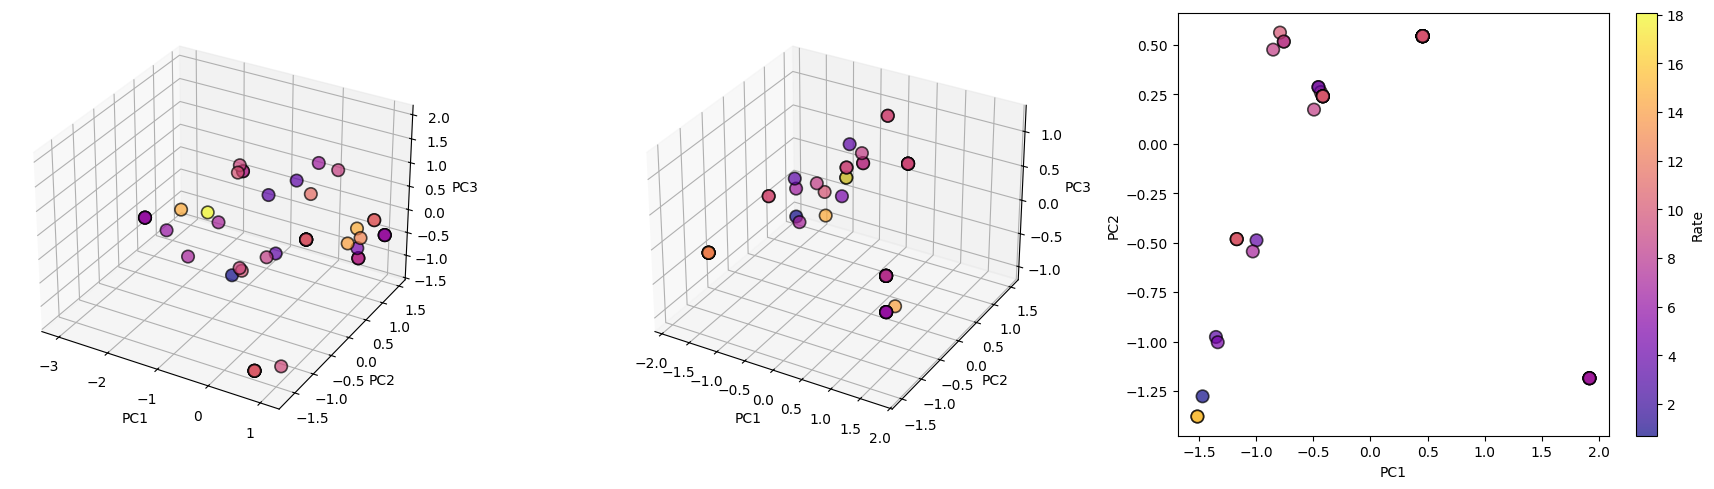

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create the plots
fig = plt.figure(figsize=(18, 5))

# Plot 1: Sector 3
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(pca_sec3[:, 0], pca_sec3[:, 1], pca_sec3[:, 2], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# Plot 2: Sector 5
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(pca_sec5[:, 0], pca_sec5[:, 1], pca_sec5[:, 2], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Plot 3: Conserved
ax3 = fig.add_subplot(133)
sc3 = ax3.scatter(pca_conserved[:, 0], pca_conserved[:, 1], c=rates, cmap='plasma', 
                 s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
plt.colorbar(sc3, ax=ax3, label='Rate')

plt.tight_layout()
plt.show()


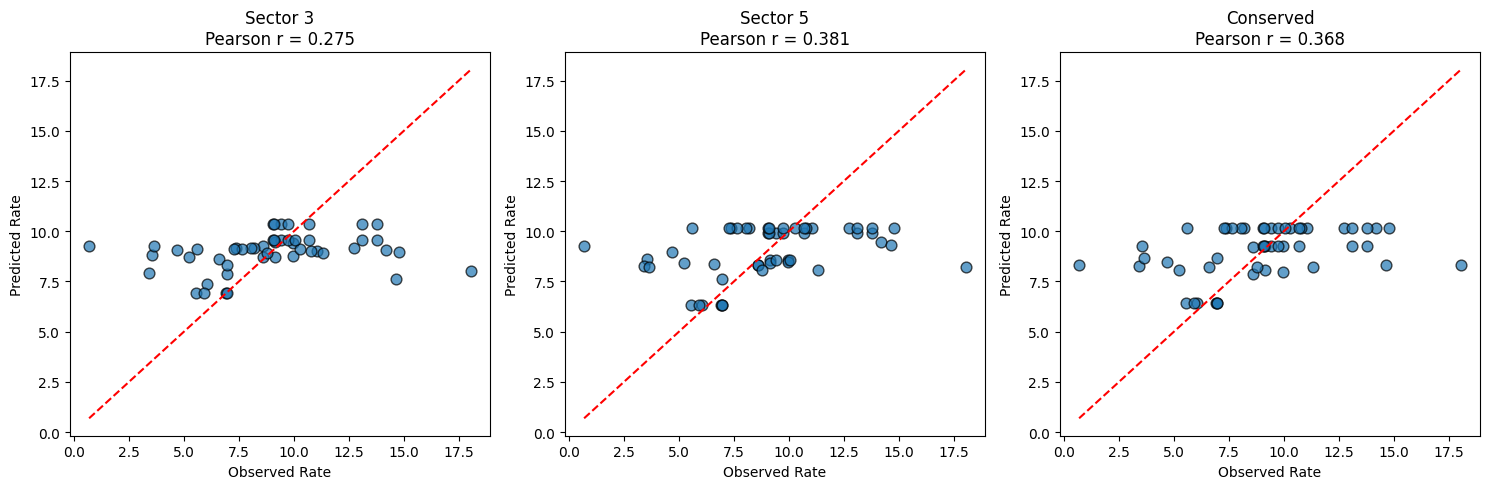

In [6]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Create the plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sector 3 regression
model_sec3 = LinearRegression()
model_sec3.fit(pca_sec3, rates)
pred_sec3 = model_sec3.predict(pca_sec3)
corr_sec3, _ = pearsonr(pred_sec3, rates)

axes[0].scatter(rates, pred_sec3, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec3.min())
max_val = max(rates.max(), pred_sec3.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_xlabel('Observed Rate')
axes[0].set_ylabel('Predicted Rate')
axes[0].set_title(f'Sector 3\nPearson r = {corr_sec3:.3f}')

# Sector 5 regression
model_sec5 = LinearRegression()
model_sec5.fit(pca_sec5, rates)
pred_sec5 = model_sec5.predict(pca_sec5)
corr_sec5, _ = pearsonr(pred_sec5, rates)

axes[1].scatter(rates, pred_sec5, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec5.min())
max_val = max(rates.max(), pred_sec5.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_xlabel('Observed Rate')
axes[1].set_ylabel('Predicted Rate')
axes[1].set_title(f'Sector 5\nPearson r = {corr_sec5:.3f}')

# Conserved regression
model_cons = LinearRegression()
model_cons.fit(pca_conserved, rates)
pred_cons = model_cons.predict(pca_conserved)
corr_cons, _ = pearsonr(pred_cons, rates)

axes[2].scatter(rates, pred_cons, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_cons.min())
max_val = max(rates.max(), pred_cons.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[2].set_xlabel('Observed Rate')
axes[2].set_ylabel('Predicted Rate')
axes[2].set_title(f'Conserved\nPearson r = {corr_cons:.3f}')

plt.tight_layout()
plt.show()

### a null? 

MSA Null PCA:
Explained variance ratio: [0.254282   0.19694656 0.11982473]
Total variance explained: 0.5711
PCA shape: (51, 3)



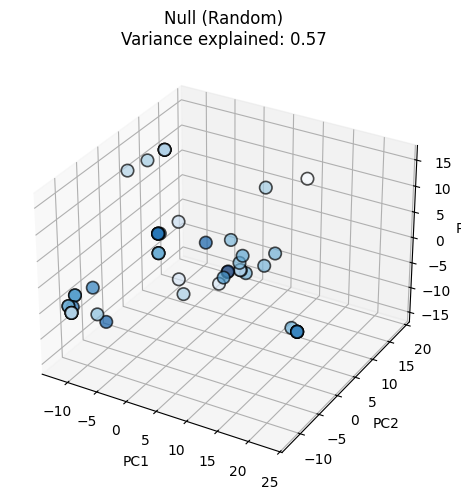

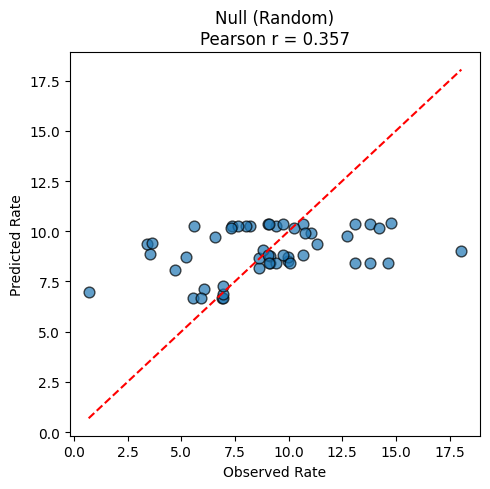

Null model Pearson correlation: 0.357


In [9]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Create random indices
# np.random.seed(42)  # for reproducibility
random_indices = np.random.choice(msa_isolates.shape[1], size=50, replace=False)

# Create null MSA
msa_null = msa_isolates[:, random_indices]


# Compute PCA for null MSA
pca_null, explained_null = compute_pca_components(msa_null)
print("MSA Null PCA:")
print(f"Explained variance ratio: {explained_null}")
print(f"Total variance explained: {np.sum(explained_null):.4f}")
print(f"PCA shape: {pca_null.shape}\n")

# Create 3D plot for null MSA
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_null[:, 0], pca_null[:, 1], pca_null[:, 2], c=rates, cmap='Blues', 
               s=80, edgecolor='black', linewidth=1.2, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'Null (Random)\nVariance explained: {np.sum(explained_null):.2f}')
plt.tight_layout()
plt.show()

# Linear regression for null MSA
model_null = LinearRegression()
model_null.fit(pca_null, rates)
pred_null = model_null.predict(pca_null)
corr_null, _ = pearsonr(pred_null, rates)

plt.figure(figsize=(5, 5))
plt.scatter(rates, pred_null, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_null.min())
max_val = max(rates.max(), pred_null.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Observed Rate')
plt.ylabel('Predicted Rate')
plt.title(f'Null (Random)\nPearson r = {corr_null:.3f}')
plt.tight_layout()
plt.show()

print(f"Null model Pearson correlation: {corr_null:.3f}")

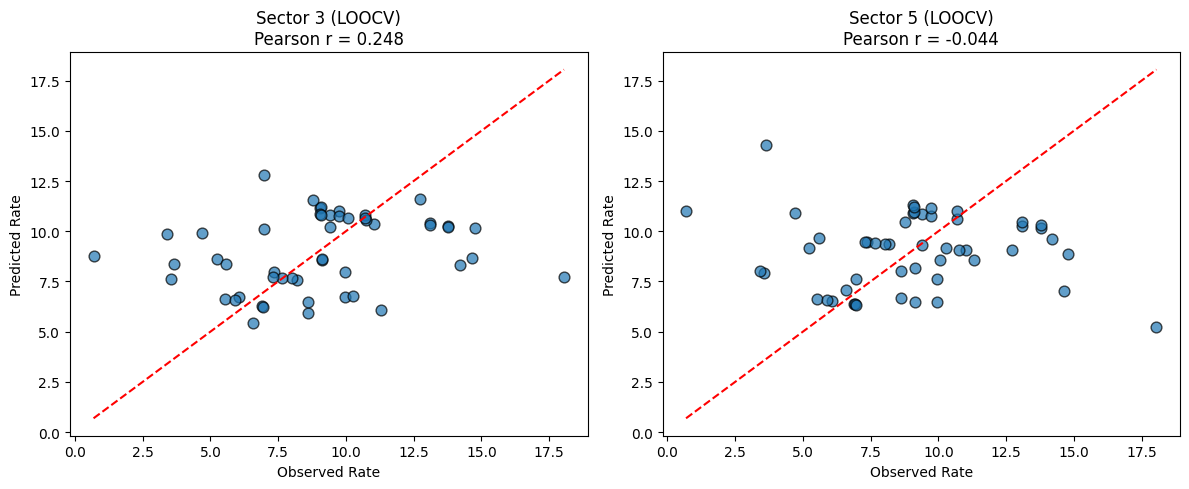

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Initialize LOOCV
loo = LeaveOneOut()
pred_sec3_loocv = np.zeros(len(rates))
pred_sec5_loocv = np.zeros(len(rates))

# Sector 3 - LOOCV
for train_idx, test_idx in loo.split(pca_sec3):
    rf_sec3 = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_sec3.fit(pca_sec3[train_idx], rates[train_idx])
    pred_sec3_loocv[test_idx] = rf_sec3.predict(pca_sec3[test_idx])

corr_sec3_loocv, _ = pearsonr(pred_sec3_loocv, rates)

axes[0].scatter(rates, pred_sec3_loocv, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec3_loocv.min())
max_val = max(rates.max(), pred_sec3_loocv.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_xlabel('Observed Rate')
axes[0].set_ylabel('Predicted Rate')
axes[0].set_title(f'Sector 3 (LOOCV)\nPearson r = {corr_sec3_loocv:.3f}')

# Sector 5 - LOOCV
for train_idx, test_idx in loo.split(pca_sec5):
    rf_sec5 = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_sec5.fit(pca_sec5[train_idx], rates[train_idx])
    pred_sec5_loocv[test_idx] = rf_sec5.predict(pca_sec5[test_idx])

corr_sec5_loocv, _ = pearsonr(pred_sec5_loocv, rates)

axes[1].scatter(rates, pred_sec5_loocv, alpha=0.7, s=60, edgecolor='black')
min_val = min(rates.min(), pred_sec5_loocv.min())
max_val = max(rates.max(), pred_sec5_loocv.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_xlabel('Observed Rate')
axes[1].set_ylabel('Predicted Rate')
axes[1].set_title(f'Sector 5 (LOOCV)\nPearson r = {corr_sec5_loocv:.3f}')

plt.tight_layout()
plt.show()